# RoadGuardian AI

## AI-Based Smart Road Damage Detection & Severity Assessment System

### Developed By
Fadia Iftikhar

### Dataset
RDD2022 (Road Damage Detection 2022)

### Objective
To analyze the RDD2022 dataset before building a CNN-based Deep Learning model.

### Technologies
- Python
- TensorFlow / Keras
- OpenCV
- NumPy
- Pandas
- Matplotlib
- CNN (EfficientNetB0)

In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
train_path = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train"
val_path = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val"

train_images = os.path.join(train_path, "images")
train_labels = os.path.join(train_path, "labels")

val_images = os.path.join(val_path, "images")
val_labels = os.path.join(val_path, "labels")

In [3]:
print("Train Folder:")
print(os.listdir(train_path))

print("\nValidation Folder:")
print(os.listdir(val_path))

Train Folder:
['labels', 'images']

Validation Folder:
['labels', 'images']


In [4]:
print("========== TRAIN DATA ==========")

print("Images :", len(os.listdir(train_images)))
print("Labels :", len(os.listdir(train_labels)))

print()

print("========== VALIDATION DATA ==========")

print("Images :", len(os.listdir(val_images)))
print("Labels :", len(os.listdir(val_labels)))

========== TRAIN DATA ==========
Images : 26869
Labels : 26869

========== VALIDATION DATA ==========
Images : 5758
Labels : 5758


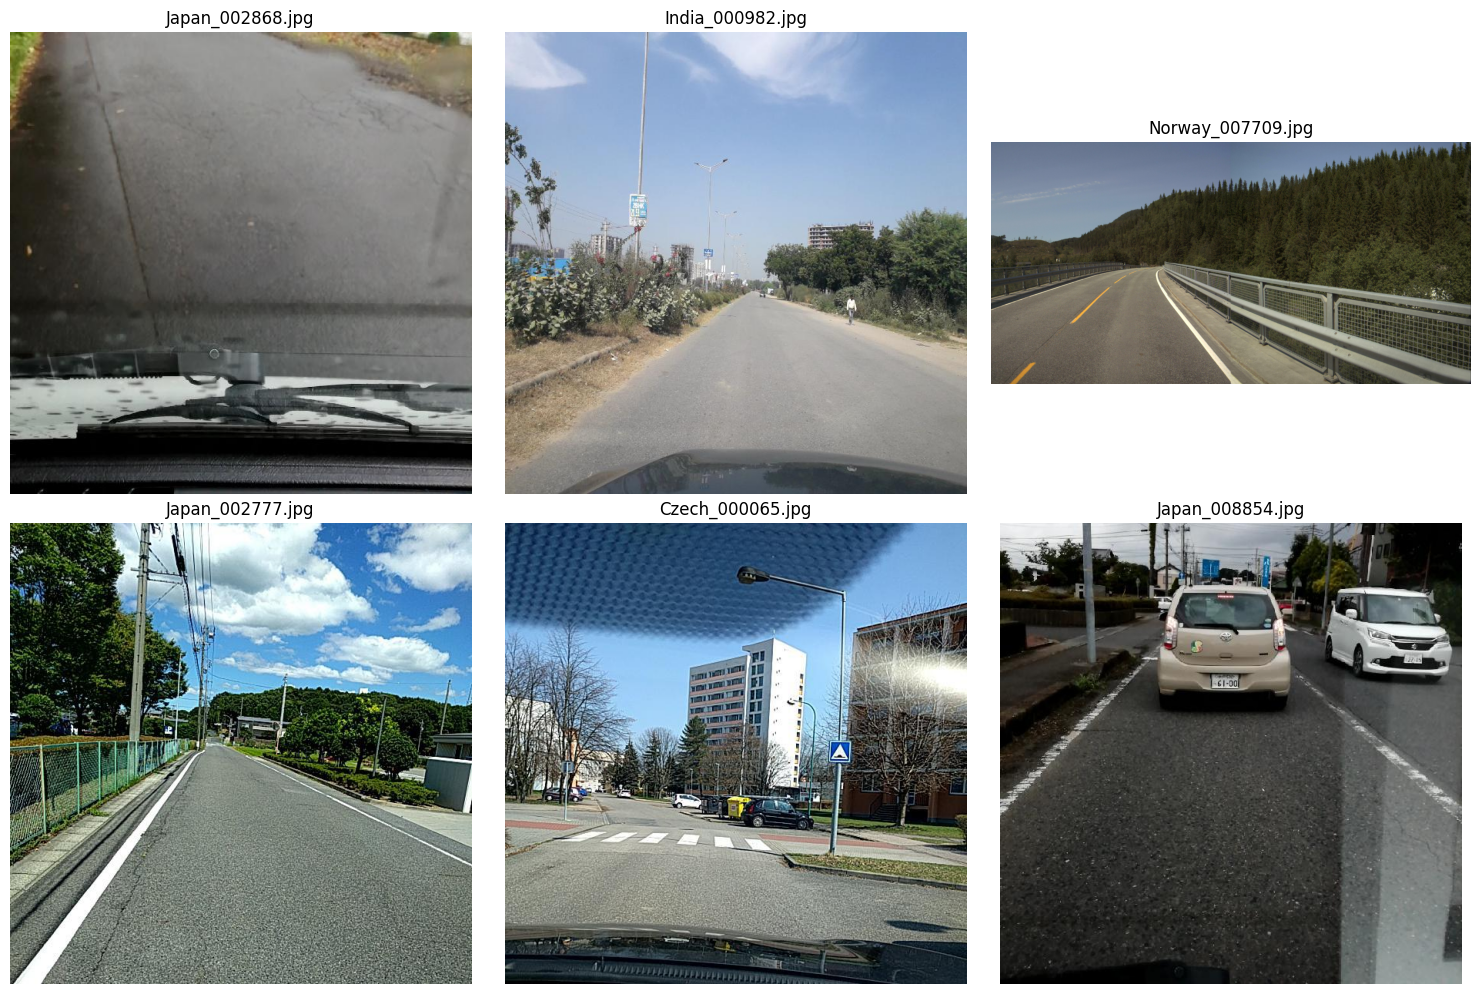

In [5]:
fig = plt.figure(figsize=(15,10))

for i in range(6):

    image_name = random.choice(os.listdir(train_images))

    image_path = os.path.join(train_images, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.title(image_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [6]:
image_name = random.choice(os.listdir(train_images))

image_path = os.path.join(train_images, image_name)

image = cv2.imread(image_path)

print("Image Name :", image_name)

print("Image Shape :", image.shape)

print("Height :", image.shape[0])

print("Width :", image.shape[1])

print("Channels :", image.shape[2])

Image Name : Czech_002330.jpg
Image Shape : (600, 600, 3)
Height : 600
Width : 600
Channels : 3


In [7]:
label_name = image_name.replace(".jpg", ".txt")

label_file = os.path.join(train_labels, label_name)

print(label_file)

/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels/Czech_002330.txt


In [8]:
with open(label_file, "r") as f:
    content = f.read()

print(content)

In [9]:
from collections import Counter

class_counts = Counter()

for label_file in os.listdir(train_labels):

    path = os.path.join(train_labels, label_file)

    with open(path, "r") as f:

        lines = f.readlines()

        for line in lines:

            if line.strip() == "":
                continue

            class_id = int(line.split()[0])

            class_counts[class_id] += 1

print("Class Distribution:\n")

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls} : {count}")

Class Distribution:

Class 0 : 18201
Class 1 : 8386
Class 2 : 7527
Class 3 : 7554
Class 4 : 4628


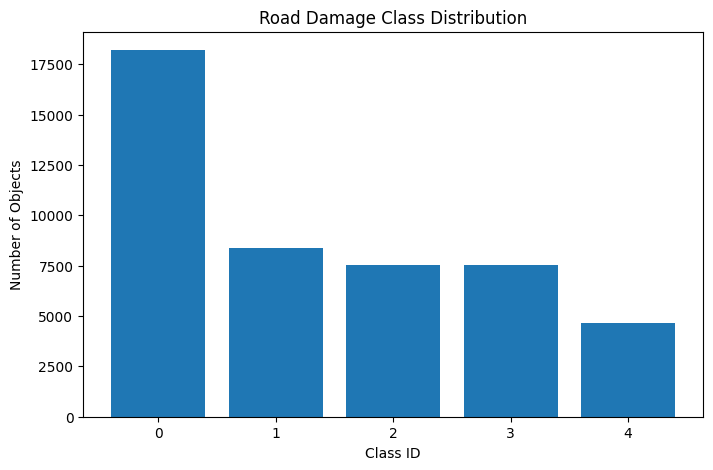

In [10]:
plt.figure(figsize=(8,5))

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Road Damage Class Distribution")

plt.xlabel("Class ID")

plt.ylabel("Number of Objects")

plt.show()

In [11]:
class_names = {

    0:"Longitudinal Crack",

    1:"Transverse Crack",

    2:"Alligator Crack",

    3:"Pothole",

    4:"Repair / Other"

}

for cls, count in sorted(class_counts.items()):

    print(class_names.get(cls),":",count)

Longitudinal Crack : 18201
Transverse Crack : 8386
Alligator Crack : 7527
Pothole : 7554
Repair / Other : 4628


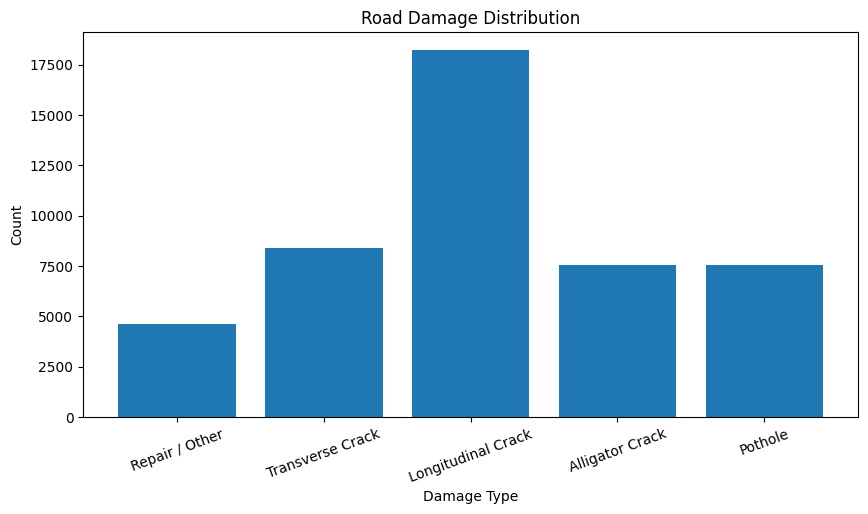

In [12]:
names = [class_names.get(i) for i in class_counts.keys()]

counts = list(class_counts.values())

plt.figure(figsize=(10,5))

plt.bar(names, counts)

plt.title("Road Damage Distribution")

plt.xlabel("Damage Type")

plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()

In [13]:
print("========== DATASET INSIGHTS ==========\n")

print("Dataset Type : Object Detection")

print("Annotation Format : YOLO")

print("Total Classes :", len(class_counts))

print("Most Common Class :", class_names[max(class_counts, key=class_counts.get)])

print("Least Common Class :", class_names[min(class_counts, key=class_counts.get)])

========== DATASET INSIGHTS ==========

Dataset Type : Object Detection
Annotation Format : YOLO
Total Classes : 5
Most Common Class : Longitudinal Crack
Least Common Class : Repair / Other


# Dataset Summary

## Dataset Name
RDD2022 (Road Damage Detection Dataset)

## Dataset Type
Object Detection

## Annotation Format
YOLO

## Total Training Images
26,869

## Total Validation Images
5,758

## Total Classes
5

### Classes

- Longitudinal Crack
- Transverse Crack
- Alligator Crack
- Pothole
- Repair / Other

## Observations

- Images belong to multiple countries.
- Labels are in YOLO format.
- Dataset is imbalanced.
- Longitudinal Crack has the highest number of samples.
- Repair / Other has the lowest number of samples.

## Conclusion

The dataset has been successfully analyzed. It is ready for preprocessing, where images and labels will be prepared for CNN-based model training.